# Hands-on tutorial: Machine Learning - basics

1.   Élément de liste
2.   Élément de liste


**Lecturer:** Dr. Habiboulaye {@gmail.com}

This hand-on tutorial will conver:

* Linear Regression
* Polynomial Regression
* Ridge Regression
(This notebook is inspired by the work of Animesh Agarwal)

## Populating the namespace

In [1]:
import numpy as np
import operator
import matplotlib.pyplot as plt
%matplotlib inline
colors = ['seagreen','blue', 'darkorange', 'indigo', 'yellow', 'purple', 'violet', 'turquoise']

## Data Generation

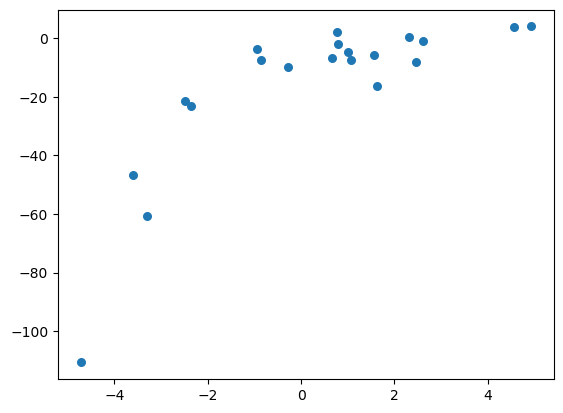

In [2]:
#@title
#Generate data
np.random.seed(0)
N = 20
x_orig = 2 - 3 * np.random.normal(0, 1, N)
y_orig = x_orig - 2 * (x_orig ** 2) + 0.5 * (x_orig ** 3) + np.random.normal(-5, 5, N)

# transforming the data to include another axis
x = x_orig[:, np.newaxis]
y = y_orig[:, np.newaxis]
plt.scatter(x,y, s=30)
plt.show()

<font color='red'>
<b>EXERCICES</b>: Replace the <b>FILL_IN</b> pattern with the correct codes then execute the cell
 </font>

## Linear Regression  

* Take a look at the scikit-learn user guide for more details on [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) and [metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics) api

rmse: 16.924817575403132
r2  : 0.6049187123282771


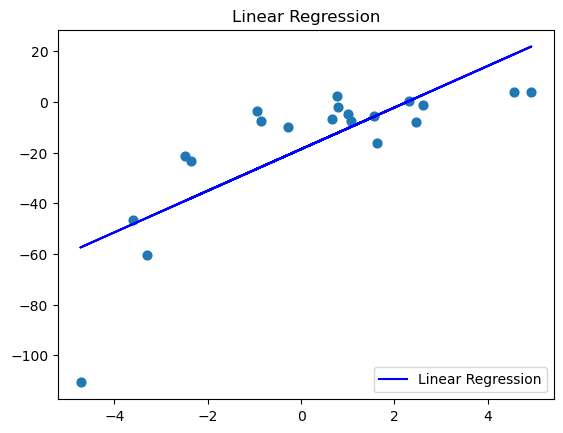

In [11]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Import the linear regression model from scikit-learn
from sklearn.linear_model import LinearRegression

# Import performance metrics
from sklearn.metrics import mean_squared_error, r2_score

# Create the linear regression model
model = LinearRegression()

# Train the model using input data x and output y
model.fit(x, y)

# Predict outputs using the trained model
y_pred = model.predict(x)

# Calculate performance metrics
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print('rmse:', rmse)
print('r2  :', r2)

# Plot the data and regression line
plt.scatter(x, y, s=40)
plt.title('Linear Regression')
plt.plot(x, y_pred, color='blue', label='Linear Regression')
plt.legend(loc="lower right")

# Save the graph
plt.savefig("linear_regression_plot.png")

# Display the graph
plt.show()

<font color='red'>
    
**Conclusion**: ??

</font>

## Polynomial Regression: linear model with polynomial features

To overcome under-fitting, we need to **increase the complexity of the model**.  
**Idea**: convert the original features into their higher order terms we will use the [**PolynomialFeatures**](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html) class provided by **scikit-learn**. Next, we train the model using Linear Regression.


instance:0: poly_degree: 1
rmse 16.924817575403132
r2 0.6049187123282771
instance:1: poly_degree: 4
rmse 5.560421255562292
r2 0.9573564003349706
instance:2: poly_degree: 10
rmse 3.3739957126007845
r2 0.9842989925127905


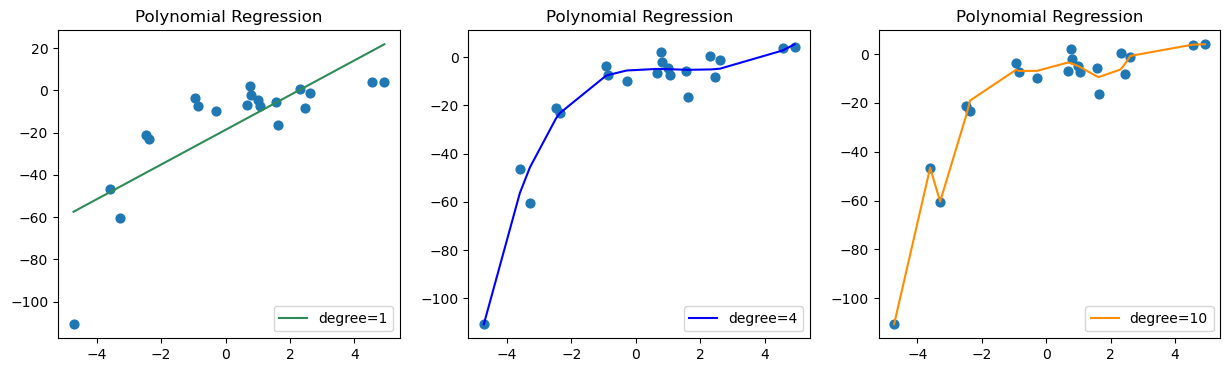

poly_features
without poly_features: [-4.7226796]
adding  poly_features: [ 1.00000000e+00 -3.29215704e+00  1.08382980e+01 -3.56813789e+01
  1.17468703e+02 -3.86725416e+02  1.27316080e+03 -4.19144529e+03
  1.37988961e+04 -4.54281330e+04  1.49556548e+05]


In [15]:
import operator
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate a new Linear Regression model
model = LinearRegression()

plt.figure(figsize=(15,4))

# Create Polynomial features with degree 1, then 4, then 10
for i, degree in enumerate([1,4,10]):
    
    # transforming the data to include another axis
    x = x_orig[:, np.newaxis]
    y = y_orig[:, np.newaxis]
    
    print('instance:{}: poly_degree: {}'.format(i,degree))
    
    # Create an instance of class PolynomialFeatures
    polynomial_features = PolynomialFeatures(degree=degree)
    
    # Create new polynomial feature matrix
    x_poly = polynomial_features.fit_transform(x)
    
    # Train the model
    model.fit(x_poly, y)
    
    # Predict using the polynomial features
    y_poly_pred = model.predict(x_poly)
    
    # Performance metrics
    rmse = np.sqrt(mean_squared_error(y, y_poly_pred))
    r2 = r2_score(y, y_poly_pred)
    
    print('rmse', rmse)
    print('r2', r2)

    # plot
    plt.subplot(1,3,1+i)
    plt.scatter(x, y, s=40)

    # sort the values of x before line plot
    sort_axis = operator.itemgetter(0)
    sorted_zip = sorted(zip(x, y_poly_pred), key=sort_axis)
    x, y_poly_pred = zip(*sorted_zip)

    plt.plot(x, y_poly_pred, color=colors[i], label='degree='+str(degree))
    plt.title('Polynomial Regression')
    plt.legend(loc="lower right")
    plt.savefig("polynomial_regression.png", dpi=300)
    plt.savefig("polynomial_regression.pdf")

plt.show()

print('poly_features')
print('without poly_features:', x[0])
print('adding  poly_features:', x_poly[0])

**Conclusion**: ??

## Ridge Regression: Overffiting and Regularization
* Take a look at the scikit-learn user guide for more details on [RidgeRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) api  
λ (i.e penalty_lambda) is the tuning parameter that decides how much we want to penalize the flexibility of our model.   
 - When λ = 0, the penalty term has no eﬀect, and the estimates produced by ridge regression will be equal to least squares.   
 - However, as λ→∞, the impact of the shrinkage penalty grows, and the ridge regression coeﬃcient estimates will approach zero.

instance:0: poly_degree: 10
rmse 3.3739957126007845
r2 0.9842989925127905
instance:1: poly_degree: 10
rmse 4.014901984466653
r2 0.977767496845675
instance:2: poly_degree: 10
rmse 4.763789291072996
r2 0.968700056361873


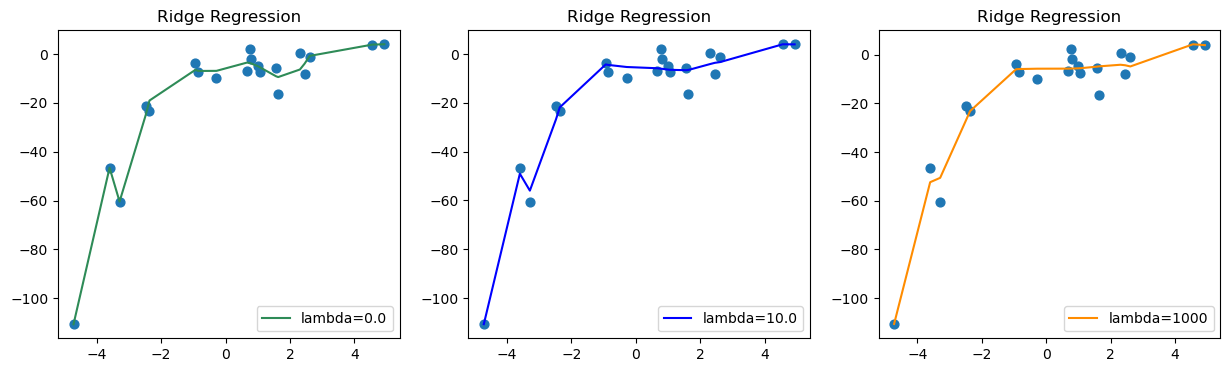

In [18]:

import operator
import numpy as np
import matplotlib.pyplot as plt

# Import the Ridge regressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

plt.figure(figsize=(15,4))

# Loop for varying the penalty_lambda to see the regulation impact
for i, penalty_lambda in enumerate([0.,10.,1000]):
    
    # transforming the data to include another axis
    x = x_orig[:, np.newaxis]
    y = y_orig[:, np.newaxis]

    print('instance:{}: poly_degree: {}'.format(i,10))

    polynomial_features = PolynomialFeatures(degree=10)
    x_poly = polynomial_features.fit_transform(x)

    # Create Ridge Regression model
    model = Ridge(alpha=penalty_lambda)

    # Train the model
    model.fit(x_poly, y)

    # Predict values
    y_poly_pred = model.predict(x_poly)

    # Performance metrics
    rmse = np.sqrt(mean_squared_error(y, y_poly_pred))
    r2 = r2_score(y, y_poly_pred)

    print('rmse', rmse)
    print('r2', r2)

    # plot
    plt.subplot(1,3,1+i)
    plt.scatter(x, y, s=40)

    # sort the values of x before line plot
    sort_axis = operator.itemgetter(0)
    sorted_zip = sorted(zip(x, y_poly_pred), key=sort_axis)
    x, y_poly_pred = zip(*sorted_zip)

    plt.plot(x, y_poly_pred, color=colors[i], label='lambda='+str(penalty_lambda))
    plt.title('Ridge Regression')
    plt.legend(loc="lower right")
    plt.savefig("ridge_regression.png", dpi=300)
    plt.savefig("ridge_regression.pdf")
plt.show()

**Conclusion**: ??

## Lasso Regression: Conduct your own experiments (bonus)
* Find Lasso model api on [scikit-learn documentation](https://scikit-learn.org/stable/) and take a look for more details

* For any question: Keep in mind that [*ChatGPT*](https://chat.openai.com/) and [*Google*](https://www.google.com/) are your friends.